<div style="
    padding:18px 20px;
    border-radius:10px;
    background:#d889a8;
    margin-bottom:18px;
">

<h1 style="
    margin:0;
    color:white;
">
Day 4 - Feature Engineering & Hyperparameter Tuning
</h1>

<p style="
    margin-top:8px;
    margin-bottom:0;
    color:white;
">
Improving a model through better features and better hyperparameter choices.
</p>

</div>

<div style="
    padding:14px 16px;
    border-radius:9px;
    background:#ffffff;
    border:1px solid #eeeeee;
    margin:12px 0;
">

<h2 style="
    margin-top:0;
    color:#d889a8;
    font-weight:bold;
">
Introduction
</h2>

<p style="color:#4a4a4a;">
A model does not improve only by changing the algorithm.
</p>

<p style="color:#4a4a4a;">
Sometimes better features and better parameter choices can make a bigger difference.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
In this notebook, I will create new features from the dataset, then tune a Random Forest model using GridSearchCV and compare it with the untuned baseline.
</p>

</div>

<div style="
    padding:14px 16px;
    border-radius:9px;
    background:#ffffff;
    border:1px solid #eeeeee;
    margin:12px 0;
">

<h2 style="
    margin-top:0;
    color:#d889a8;
    font-weight:bold;
">
Topics
</h2>

<ul style="color:#4a4a4a;">
    <li>Feature engineering</li>
    <li>Creating new features</li>
    <li>Binning and encoding</li>
    <li>Hyperparameters vs parameters</li>
    <li>GridSearchCV</li>
    <li>Cross-validation</li>
    <li>Model tuning and comparison</li>
</ul>

</div>

<h2 style="
    color:#9b7b8a;
    font-weight:bold;
">
Import Libraries
</h2>

In [91]:
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

<h1 style="
    color:#9b7b8a;
    font-weight:bold;
">
Lesson Content
</h1>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
4.1 - Why Feature Engineering Matters
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
Feature engineering means creating or transforming features so the model can learn useful patterns more easily.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
A better feature can sometimes improve the model more than changing the algorithm itself.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
4.2 - Common Feature Engineering Techniques
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
Some common techniques are:
</p>

<ul style="color:#4a4a4a;">
    <li><b>Creating features:</b> combine existing columns to make a new feature.</li>
    <li><b>Binning:</b> group continuous values into ranges.</li>
    <li><b>One-hot encoding:</b> convert categorical values into numerical columns.</li>
    <li><b>Datetime extraction:</b> extract information such as month or day of week from dates.</li>
    <li><b>Scaling:</b> put numerical features on a similar range.</li>
</ul>

<p style="color:#4a4a4a;">
The best technique depends on the dataset and the type of model.
</p>

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-bottom:0;
">
Applied in Hands-On: Step 1.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
4.3 - Parameters vs Hyperparameters
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
A parameter is learned by the model during training.
</p>

<p style="color:#4a4a4a;">
A hyperparameter is chosen before training and controls how the model learns.
</p>

<p style="color:#4a4a4a;">
For example:
</p>

<ul style="color:#4a4a4a;">
    <li>A model coefficient is a parameter.</li>
    <li><code>max_depth</code> in a Decision Tree is a hyperparameter.</li>
    <li><code>n_estimators</code> in a Random Forest is a hyperparameter.</li>
    <li><code>alpha</code> in Ridge is a hyperparameter.</li>
</ul>

<p style="color:#4a4a4a;">
Choosing hyperparameters manually can take time, so tuning methods such as GridSearchCV are used to search for better values.
</p>

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-bottom:0;
">
Applied in Hands-On: Steps 2 and 3.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
4.4 - GridSearchCV
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
GridSearchCV tries different combinations of hyperparameters and evaluates each one using cross-validation.
</p>

<p style="color:#4a4a4a;">
For example, if I test:
</p>

<ul style="color:#4a4a4a;">
    <li>2 values for <code>n_estimators</code></li>
    <li>3 values for <code>max_depth</code></li>
    <li>2 values for <code>min_samples_split</code></li>
    <li>5 cross-validation folds</li>
</ul>

<p style="color:#4a4a4a;">
This gives <b>12 hyperparameter combinations</b>, and each combination is evaluated across 5 folds, so the model will be fitted <b>60 times</b>.
</p>

<p style="color:#4a4a4a;">
After the search, GridSearchCV gives:
</p>

<ul style="color:#4a4a4a;">
    <li><code>best_params_</code> → best hyperparameter combination</li>
    <li><code>best_score_</code> → best cross-validation score</li>
    <li><code>best_estimator_</code> → model with the best settings</li>
</ul>

<p style="color:#4a4a4a;">
For larger search spaces, RandomizedSearchCV can be faster because it tests only a sample of the possible combinations.
</p>

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-bottom:0;
">
Applied in Hands-On: Steps 2 and 3.
</p>

</div>

<h1 style="
    color:#9b7b8a;
    font-weight:bold;
">
Hands-On Lab
</h1>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
In this lab, I will continue using the Pima Indians Diabetes Dataset from Week 3.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will create new features, tune the same Random Forest model used in Week 3, and compare the tuned model with the untuned baseline using cross-validation.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Dataset
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
I will use the same Pima Indians Diabetes Dataset from Week 3 to keep the model comparison consistent.
</p>

<p style="
    color:#4a4a4a;
">
The dataset contains health-related features such as glucose, BMI, age, blood pressure, and insulin.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
The target variable is <code>Outcome</code>, where <code>0</code> means no diabetes and <code>1</code> means diabetes.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Load and Explore the Dataset
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
Before creating new features, I will first load the dataset and check its structure.
</p>

</div>

In [72]:
# Load the same dataset used in Week 3
df = pd.read_csv("diabetes.csv")

# Preview the first five rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [73]:
# Check the dataset size and column names
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#4a4a4a;
">
The dataset contains <b>768 rows</b> and <b>9 columns</b>.
</p>

<p style="
    color:#4a4a4a;
">
It includes eight numerical input features and one binary target column, <code>Outcome</code>.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
No missing values were reported, so the dataset is ready for the feature engineering step.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Step 1 - Create New Features
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin-top:0;
">
In this step, I will create two new features from the existing patient information.
</p>

<p style="color:#4a4a4a;">
<b>BMI Category:</b> groups BMI values into ranges to represent different body weight levels.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
<b>Glucose-Age Risk:</b> combines glucose level and age because both can be related to diabetes risk.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will create two engineered features: one to group patients by BMI level and another to combine glucose level with age.
</p>

</div>

In [76]:
# Group BMI values into categories
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[-0.1, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Combine glucose and age into one risk-related feature
df["Glucose_Age_Risk"] = df["Glucose"] * df["Age"]

# Preview the new features
df[
    ["BMI", "BMI_Category", "Glucose", "Age", "Glucose_Age_Risk"]
].head(10)

,BMI,BMI_Category,Glucose,Age,Glucose_Age_Risk
0,33.6,Obese,148,50,7400
1,26.6,Overweight,85,31,2635
2,23.3,Normal,183,32,5856
3,28.1,Overweight,89,21,1869
4,43.1,Obese,137,33,4521
5,25.6,Overweight,116,30,3480
6,31.0,Obese,78,26,2028
7,35.3,Obese,115,29,3335
8,30.5,Obese,197,53,10441
9,0.0,Underweight,125,54,6750


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
The two engineered features were created successfully.
</p>

<p style="color:#4a4a4a;">
<code>BMI_Category</code> groups patients based on their BMI range, while <code>Glucose_Age_Risk</code> combines glucose level and age into one numerical feature.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
For example, a patient with glucose level 148 and age 50 has a <code>Glucose_Age_Risk</code> value of 7400.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will check how the engineered features are distributed before preparing the data for modeling.
</p>

</div>

In [77]:
# Count patients in each BMI category
print(df["BMI_Category"].value_counts())

# Check the distribution of the numerical engineered feature
print("\nGlucose-Age Risk Summary:")
print(df["Glucose_Age_Risk"].describe())

BMI_Category
Obese          465
Overweight     180
Normal         108
Underweight     15
Name: count, dtype: int64

Glucose-Age Risk Summary:
count      768.000000
mean      4117.595052
std       2104.629026
min          0.000000
25%       2603.000000
50%       3465.500000
75%       5130.750000
max      12998.000000
Name: Glucose_Age_Risk, dtype: float64


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
Most patients are in the <code>Obese</code> BMI category, with <b>465 patients</b>, while only <b>15 patients</b> are in the <code>Underweight</code> category.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
The <code>Glucose_Age_Risk</code> feature has a mean value of approximately <b>4,118</b>, with values ranging from <b>0</b> to <b>12,998</b>.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Prepare the Data for Modeling
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
Before training the models, I will separate the input features from the target variable.
</p>

</div>

In [78]:
# Separate the input features from the target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 10)
Target shape: (768,)


<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Split the Data
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
I will use the same train/test split settings from Week 3 to keep the comparison consistent.
</p>

</div>

In [79]:
# Use the same train/test split settings from Week 3
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (614, 10)
Testing shape: (154, 10)


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
The dataset was split into <b>614 training samples</b> and <b>154 testing samples</b>. Both sets contain the same <b>10 input features</b>, including the two engineered features.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Encode Categorical Features
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
The engineered <code>BMI_Category</code> feature is categorical, so I will convert it into numerical columns before training the Random Forest model.
</p>

</div>

In [80]:
# Convert categorical features into numerical columns
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

# Make sure train and test contain the same columns
x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Training shape after encoding:", x_train.shape)
print("Testing shape after encoding:", x_test.shape)

Training shape after encoding: (614, 12)
Testing shape after encoding: (154, 12)


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
After encoding <code>BMI_Category</code>, the number of input features increased from <b>10</b> to <b>12</b>. Both the training and testing sets now contain the same numerical features.
</p>

</div>

<div style="
    background:#fff7fa;
    border-left:4px solid #d889a8;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#d889a8;
    font-weight:bold;
    margin-top:0;
">
Question
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
How well does the untuned Random Forest from Week 3 perform using 5-fold cross-validation?
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will reuse the same untuned Random Forest configuration from Week 3 and evaluate it using 5-fold cross-validation.
</p>

</div>

In [81]:
# Create the same untuned Random Forest used in Week 3
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Evaluate the baseline using 5-fold cross-validation
baseline_cv_scores = cross_val_score(
    baseline_model,
    x_train,
    y_train,
    cv=5,
    scoring="f1"
)

# Calculate the mean F1-score
baseline_cv_f1 = baseline_cv_scores.mean()

print("Baseline CV scores:", baseline_cv_scores)
print("Baseline mean CV F1-score:", baseline_cv_f1)

Baseline CV scores: [0.57831325 0.70731707 0.6097561  0.7027027  0.675     ]
Baseline mean CV F1-score: 0.6546178252892917


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="
    color:#4a4a4a;
">
The untuned Random Forest produced F1-scores ranging from approximately <b>0.578</b> to <b>0.707</b> across the five folds.
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
The mean cross-validation F1-score was approximately <b>0.655</b>, which will be used as the baseline for comparison with the tuned model.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:12px;
    padding:18px;
    margin:14px 0 20px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    font-size:18px;
    margin-top:0;
    margin-bottom:16px;
">
Step 1 Journey
</p>

<div style="
    display:flex;
    flex-wrap:wrap;
    align-items:center;
    gap:8px;
    color:#4a4a4a;
    font-size:15px;
">

<span style="background:#f8f8f8; padding:8px 12px; border-radius:8px;">
Raw Dataset
</span>

<span style="color:#d889a8; font-weight:bold;">→</span>

<span style="background:#f8f8f8; padding:8px 12px; border-radius:8px;">
Explore
</span>

<span style="color:#d889a8; font-weight:bold;">→</span>

<span style="background:#f8f8f8; padding:8px 12px; border-radius:8px;">
Feature Engineering
</span>

<span style="color:#d889a8; font-weight:bold;">→</span>

<span style="background:#f8f8f8; padding:8px 12px; border-radius:8px;">
Split
</span>

<span style="color:#d889a8; font-weight:bold;">→</span>

<span style="background:#f8f8f8; padding:8px 12px; border-radius:8px;">
Encoding
</span>

<span style="color:#d889a8; font-weight:bold;">→</span>

<span style="
    background:#f3eef5;
    padding:8px 12px;
    border-radius:8px;
    color:#8f748f;
    font-weight:bold;
">
Baseline CV F1 = 0.655
</span>

</div>

</div>

<div style="
    background:#fff7fa;
    border-left:4px solid #d889a8;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#d889a8;
    font-weight:bold;
    margin-top:0;
">
Question
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
Which Random Forest settings should be tested to improve the baseline cross-validation F1-score of 0.655?
</p>

</div>

<h2 style="color:#d889a8; font-weight:bold;">
Parameters vs Hyperparameters
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="color:#4a4a4a;">
<b>Parameters</b> are values learned by the model during training.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
<b>Hyperparameters</b> are settings chosen before training, such as
<code>n_estimators</code>, <code>max_depth</code>, and
<code>min_samples_split</code> in Random Forest.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Step 2 - Define the Hyperparameter Grid
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
Instead of choosing Random Forest settings manually, I will test several possible hyperparameter values using GridSearchCV.
</p>

</div>

In [82]:
# Define the Random Forest hyperparameters to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

# Show the search grid
param_grid

{'n_estimators': [100, 200],
 'max_depth': [5, 10, None],
 'min_samples_split': [2, 5]}

2 × 3 × 2 = 12 combinations.

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
This grid contains 12 hyperparameter combinations. With 5-fold cross-validation, GridSearchCV will evaluate a total of 60 model fits.
</p>

</div>

<div style="
    background:#fff7fa;
    border-left:4px solid #d889a8;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#d889a8;
    font-weight:bold;
    margin-top:0;
">
Question
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
Which hyperparameter combination gives the best F1-score across 5-fold cross-validation?
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Step 3 - Run GridSearchCV
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
GridSearchCV will test every hyperparameter combination using 5-fold cross-validation and select the combination with the highest F1-score.
</p>

</div>

In [83]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42
)

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Test all hyperparameter combinations
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the v

In [85]:
# Show the best hyperparameter combination
print("Best Parameters:")
print(grid_search.best_params_)

# Show the best cross-validation F1-score
print("\nBest CV F1-score:", grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Best CV F1-score: 0.6546178252892917


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
GridSearchCV selected <code>max_depth=None</code>, <code>min_samples_split=2</code>, and <code>n_estimators=100</code> as the best combination.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
The best cross-validation F1-score was approximately <b>0.655</b>, which is the same as the untuned baseline. This means the tested hyperparameter combinations did not improve the baseline model.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="color:#9b7b8a; font-weight:bold; margin-top:0;">
Note
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
I will inspect the GridSearchCV results to compare the tested hyperparameter combinations instead of looking only at the best one.
</p>

</div>

In [92]:
# Store all GridSearchCV results
grid_results = pd.DataFrame(grid_search.cv_results_)

# Show the best hyperparameter combinations
grid_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
8,100,None,2,0.654618,1
7,200,10,5,0.652903,2
10,100,None,5,0.650640,3
5,200,10,2,0.647400,4
4,100,10,2,0.644287,5
2,100,5,5,0.643119,6
6,100,10,5,0.642763,7
0,100,5,2,0.635533,8
11,200,None,5,0.635139,9
3,200,5,5,0.634117,10


<p style="
    color:#3F4A52;
    background:#EAF3F5;
    padding:10px 12px;
    border-radius:8px;
">
<b style="color:#2F6F7E;">Observation:</b><br>
The best hyperparameter combination was <code>n_estimators=100</code>, <code>max_depth=None</code>, and <code>min_samples_split=2</code>, with the highest cross-validation F1-score of about <b>0.655</b>.<br><br>

The next best combinations produced very similar scores, which shows that the model performance did not change dramatically across the tested settings.
</p>


<p style="
    color:#3F4A52;
    background:#F6F9FA;
    padding:10px 12px;
    border-left:4px solid #2F6F7E;
">
<b style="color:#2F6F7E;">What does this mean?</b><br>
The Random Forest was fairly stable across several hyperparameter combinations. The best setup was only slightly better than the others, so tuning did not create a large performance improvement.
</p>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Step 4 - Compare Baseline and Tuned CV Scores
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
I will compare the untuned Random Forest cross-validation score with the best score found by GridSearchCV.
</p>

</div>

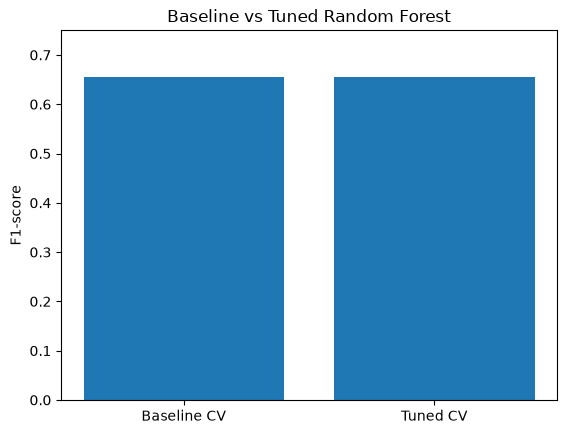

In [86]:
# Compare baseline and tuned cross-validation scores
scores = [baseline_cv_f1, grid_search.best_score_]
labels = ["Baseline CV", "Tuned CV"]

plt.bar(labels, scores)
plt.ylabel("F1-score")
plt.title("Baseline vs Tuned Random Forest")
plt.ylim(0, 0.75)
plt.show()

<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
The baseline and tuned Random Forest achieved the same mean cross-validation F1-score of approximately <b>0.655</b>.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
This shows that the tested hyperparameter combinations did not improve the baseline model. GridSearchCV confirmed that the original Random Forest settings were already the best choice within the tested search grid.
</p>

</div>

<div style="
    background:#fff7fa;
    border-left:4px solid #d889a8;
    border-radius:8px;
    padding:13px 15px;
    margin:12px 0 16px 0;
">

<p style="
    color:#d889a8;
    font-weight:bold;
    margin-top:0;
">
Next Question
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
Which engineered feature and which hyperparameter had the strongest effect on the tuned model?
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Step 5 - Identify the Most Important Feature and Hyperparameter
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#4a4a4a;
    margin:0;
">
In this step, I will check which engineered feature contributed more to the Random Forest and which hyperparameter had the strongest effect during tuning.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will use the feature importances from the best Random Forest model to compare the engineered features.
</p>

</div>

In [87]:
# Get the best Random Forest model
best_model = grid_search.best_estimator_

# Create a table of feature importances
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show the top features
feature_importance

,Feature,Importance
1,Glucose,0.226798
8,Glucose_Age_Risk,0.171706
5,BMI,0.124696
6,DiabetesPedigreeFunction,0.106853
7,Age,0.090118
2,BloodPressure,0.071670
0,Pregnancies,0.064930
4,Insulin,0.055851
3,SkinThickness,0.052593
11,BMI_Category_Obese,0.022113


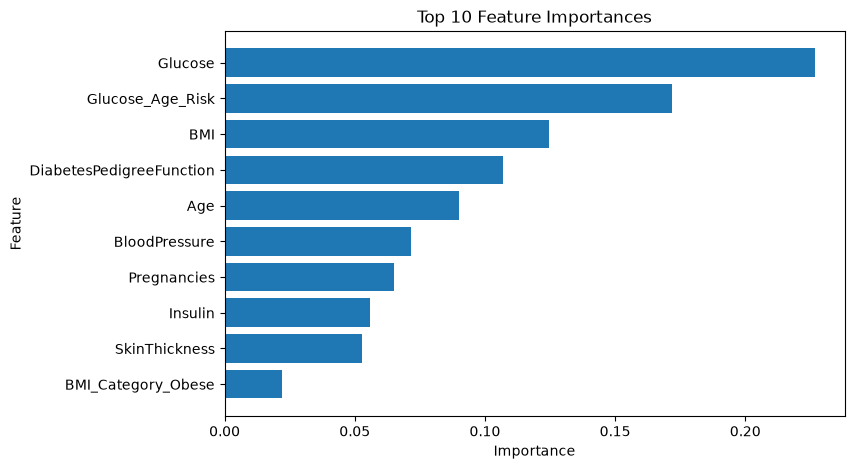

In [94]:
# Visualize the top 10 most important features
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()
plt.show()

In [88]:
# Combine the importance of all BMI_Category dummy columns
bmi_category_importance = feature_importance.loc[
    feature_importance["Feature"].str.startswith("BMI_Category_"),
    "Importance"
].sum()

# Get the importance of Glucose_Age_Risk
glucose_age_importance = feature_importance.loc[
    feature_importance["Feature"] == "Glucose_Age_Risk",
    "Importance"
].sum()

print("BMI Category Importance:", bmi_category_importance)
print("Glucose-Age Risk Importance:", glucose_age_importance)

BMI Category Importance: 0.034786083022948396
Glucose-Age Risk Importance: 0.17170574480655384


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
Among the engineered features, <code>Glucose_Age_Risk</code> had the stronger influence on the Random Forest model.
</p>

<p style="color:#4a4a4a;">
Its importance was approximately <b>0.172</b>, while the combined importance of the <code>BMI_Category</code> dummy features was approximately <b>0.035</b>.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
This suggests that combining glucose level and age provided more useful information to the model than grouping BMI into categories.
</p>

</div>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:12px 14px;
    margin:10px 0 12px 0;
">

<p style="
    color:#9b7b8a;
    font-weight:bold;
    margin-top:0;
">
Note
</p>

<p style="
    color:#4a4a4a;
    margin-bottom:0;
">
I will compare the average cross-validation F1-score across the tested values to see which hyperparameter had the strongest effect.
</p>

</div>

In [89]:
# Convert GridSearchCV results into a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Include None when comparing max_depth values
depth_values = cv_results["param_max_depth"].astype(object).fillna("None")

depth_effect = cv_results.groupby(
    depth_values
)["mean_test_score"].mean()

# Compare min_samples_split values
split_effect = cv_results.groupby(
    "param_min_samples_split"
)["mean_test_score"].mean()

# Compare n_estimators values
trees_effect = cv_results.groupby(
    "param_n_estimators"
)["mean_test_score"].mean()

print("max_depth effect:")
print(depth_effect)

print("\nmin_samples_split effect:")
print(split_effect)

print("\nn_estimators effect:")
print(trees_effect)

max_depth effect:
param_max_depth
5       0.636418
10      0.646839
None    0.641532
Name: mean_test_score, dtype: float64

min_samples_split effect:
param_min_samples_split
2    0.640079
5    0.643114
Name: mean_test_score, dtype: float64

n_estimators effect:
param_n_estimators
100    0.645160
200    0.638032
Name: mean_test_score, dtype: float64


In [90]:
parameter_effect = {
    "max_depth": depth_effect.max() - depth_effect.min(),
    "min_samples_split": split_effect.max() - split_effect.min(),
    "n_estimators": trees_effect.max() - trees_effect.min()
}

parameter_effect = pd.Series(parameter_effect).sort_values(
    ascending=False
)

print(parameter_effect)

max_depth            0.010420
n_estimators         0.007128
min_samples_split    0.003035
dtype: float64


<div style="
    background:#f3eef5;
    border:1px solid #e4dbe8;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<p style="
    color:#8f748f;
    font-weight:bold;
    margin-top:0;
">
Observation
</p>

<p style="color:#4a4a4a;">
Among the tested hyperparameters, <code>max_depth</code> had the strongest effect on the cross-validation F1-score.
</p>

<p style="color:#4a4a4a;">
Its effect range was approximately <b>0.010</b>, compared with about <b>0.007</b> for <code>n_estimators</code> and <b>0.003</b> for <code>min_samples_split</code>.
</p>

<p style="color:#4a4a4a; margin-bottom:0;">
However, the differences were small overall, which is consistent with the result that tuning did not improve the baseline F1-score.
</p>

</div>

<h2 style="
    color:#d889a8;
    font-weight:bold;
">
Final Takeaway
</h2>

<div style="
    background:#ffffff;
    border:1px solid #eeeeee;
    border-radius:9px;
    padding:14px 16px;
    margin:10px 0 18px 0;
">

<ul style="
    color:#4a4a4a;
    margin-bottom:0;
">

<li>
I created two new features: <code>BMI_Category</code> and <code>Glucose_Age_Risk</code>.
</li>

<li>
<code>Glucose_Age_Risk</code> had the higher importance, with a value of about <b>0.172</b>.
</li>

<li>
The Random Forest configuration from Week 3 achieved a mean cross-validation F1-score of about <b>0.655</b> when reevaluated in this notebook.
</li>

<li>
GridSearchCV selected <code>max_depth=None</code>, <code>min_samples_split=2</code>, and <code>n_estimators=100</code>.
</li>

<li>
The tuned model also achieved an F1-score of about <b>0.655</b>, so tuning did not improve the baseline in this search.
</li>

<li>
Among the tested hyperparameters, <code>max_depth</code> had the strongest effect on the cross-validation score.
</li>

</ul>

</div>